In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uciml/default-of-credit-card-clients-dataset")

print("Path to dataset files:", path)

100%|██████████| 0.98M/0.98M [00:00<00:00, 1.62MB/s]

Extracting files...
Path to dataset files: /Users/farahamorri/.cache/kagglehub/datasets/uciml/default-of-credit-card-clients-dataset/versions/1


In [32]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df = pd.read_csv(path+'/UCI_Credit_Card.csv',index_col=0)

In [33]:
df.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
ID,,,,,,,,,,,,,,,,,,,,,
1,20000.0,2,2,1,24,2,2,-1,-1,-2,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
2,120000.0,2,2,2,26,-1,2,0,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
3,90000.0,2,2,2,34,0,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
4,50000.0,2,2,1,37,0,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
5,50000.0,1,2,1,57,-1,0,-1,0,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [25]:
df.columns

Index(['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2',
       'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default.payment.next.month'],
      dtype='object')

In [37]:
df.rename(columns={'default.payment.next.month': 'IsDefault'}, inplace=True)

X = df.drop('IsDefault', axis=1)
y = df['IsDefault']

In [38]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Data ready ! train size : {X_train_scaled.shape}")

Data ready ! train size : (24000, 23)


In [39]:
print(df.isnull().sum())

LIMIT_BAL    0
SEX          0
EDUCATION    0
MARRIAGE     0
AGE          0
PAY_0        0
PAY_2        0
PAY_3        0
PAY_4        0
PAY_5        0
PAY_6        0
BILL_AMT1    0
BILL_AMT2    0
BILL_AMT3    0
BILL_AMT4    0
BILL_AMT5    0
BILL_AMT6    0
PAY_AMT1     0
PAY_AMT2     0
PAY_AMT3     0
PAY_AMT4     0
PAY_AMT5     0
PAY_AMT6     0
IsDefault    0
dtype: int64


In [61]:
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

df.drop_duplicates(inplace=True)

print(f"New dataset shape: {df.shape}")

Number of duplicate rows: 35
New dataset shape: (29965, 24)


In [62]:
import matplotlib.pyplot as plt

target_counts = df['IsDefault'].value_counts(normalize=True) * 100
print(target_counts)

IsDefault
0    77.874187
1    22.125813
Name: proportion, dtype: float64


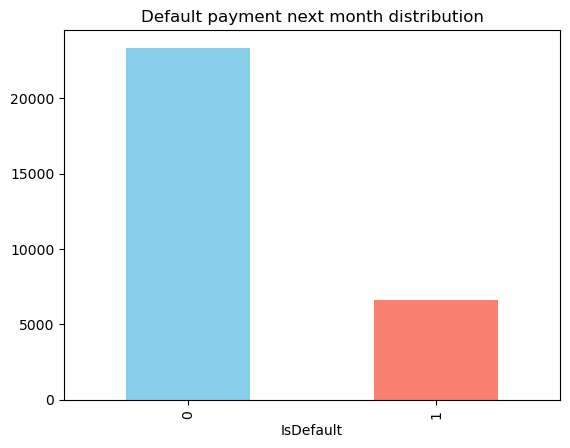

In [63]:
df['IsDefault'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title("Default payment next month distribution")
plt.show()

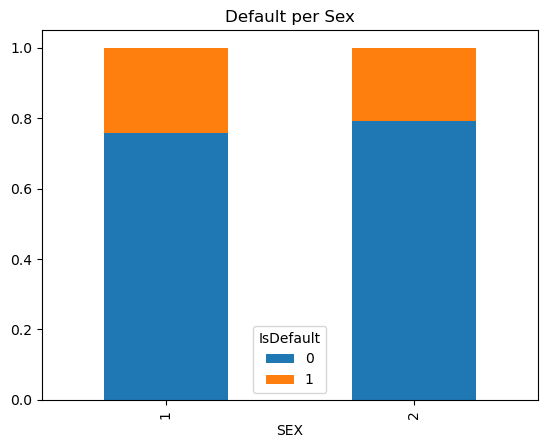

In [64]:
pd.crosstab(df['SEX'], df['IsDefault'], normalize='index').plot(kind='bar', stacked=True)
plt.title("Default per Sex")
plt.show()

In [65]:
bias_check = pd.crosstab(df['SEX'], df['IsDefault'], normalize='index')
print(bias_check)

from sklearn.utils.class_weight import compute_class_weight
import numpy as np

weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
print(f"Recommended weights : Class 0 -> {weights[0]:.2f}, Class 1 -> {weights[1]:.2f}")

IsDefault         0         1
SEX                          
1          0.758380  0.241620
2          0.792107  0.207893
Recommended weights : Class 0 -> 0.64, Class 1 -> 2.25



---

## 📊 1. Data Exploration & Preprocessing 

### 1.1 Dataset Overview
For this project, we utilize the **UCI Credit Card Clients Dataset**. The goal is to predict the binary variable `IS_DEFAULT` (1 if the client defaults, 0 otherwise).
* **Size:** 30,000 instances.
* **Features:** 23 variables including demographic data (Age, Sex, Marriage), credit history, and payment records.

### 1.2 Data Integrity & Cleaning
Before training, a rigorous data health check was performed:
* **Missing Values:** No null values were detected across the 24 columns.
* **Duplicates:** Duplicate entries were identified and removed to prevent data leakage.
* **Scaling:** Since we plan to use a **Neural Network (MLP)** and perform **FGSM Adversarial Attacks**, all numerical features were standardized using `StandardScaler`. This ensures that the gradients used in the attack are not biased by the scale of features (e.g., comparing Age vs. Bill Amount).



---

## ⚖️ 2. Preliminary Bias & Imbalance Analysis

### 2.1 Class Imbalance
The target variable `IS_DEFAULT` shows a clear imbalance:
* **Class 0 (No Default):** 77.88%
* **Class 1 (Default):** 22.12%

**Technical Justification:** To prevent the model from converging toward a "majority-class classifier" (which would yield high accuracy but zero recall for defaults), we computed **balanced class weights**. 
* **Calculated Weights:** $W_0 \approx 0.64$ and $W_1 \approx 2.25$.
* These weights will be passed to the `CrossEntropyLoss` function in PyTorch to penalize misclassifications of the minority class more heavily.

### 2.2 Initial Bias Audit (Group Fairness)
We analyzed the distribution of defaults across the sensitive attribute **SEX** (1: Male, 2: Female).

| Gender | Non-Default (0) | Default (1) |
| :--- | :--- | :--- |
| **Male** | 75.83% | **24.17%** |
| **Female** | 79.22% | **20.78%** |

**Observation:** There is an inherent 3.39% gap in default rates between genders in the raw data. 
* **Risk:** The model might learn to associate "Male" with higher risk.
* **Next Step:** This serves as our baseline. After training the model, we will measure the **Disparate Impact** to see if the model amplifies this gap.

---
